## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/master/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text = "".join(text).lower()

print(len(text))
assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

100225
OK!


### Data loading: "Евгений Онегин"


In [4]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text2 = iofile.readlines()
    
text2 = [x.replace('\t\t', '') for x in text2]

--2026-08-02 11:33:00--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt.4’

onegin.txt.4        100%[===================>] 256.37K  --.-KB/s    in 0.03s   

2026-08-02 11:33:00 (9.57 MB/s) - ‘onegin.txt.4’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

Put all the characters, that you've seen in the text, into variable `tokens`.

In [5]:
text2 = "".join(text2).lower()

In [6]:
text2 = text2.replace(" ", "_")

allowed_symbols = set("абвгдеёжзийклмнопрстуфхцчшщъыьэюя_.,?!")

text2 = "".join(ch for ch in text2 if ch in allowed_symbols)

tokens = sorted(allowed_symbols)

print(tokens)
print(len(tokens))

['!', ',', '.', '?', '_', 'а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я', 'ё']
38


Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [7]:
idx_for_token = dict()
token_to_idx = dict()
i = 0

for symbol in tokens:
    idx_for_token[i] = symbol
    token_to_idx[symbol] = i
    i += 1
print(token_to_idx)
print(idx_for_token)
print(len(token_to_idx))

{'!': 0, ',': 1, '.': 2, '?': 3, '_': 4, 'а': 5, 'б': 6, 'в': 7, 'г': 8, 'д': 9, 'е': 10, 'ж': 11, 'з': 12, 'и': 13, 'й': 14, 'к': 15, 'л': 16, 'м': 17, 'н': 18, 'о': 19, 'п': 20, 'р': 21, 'с': 22, 'т': 23, 'у': 24, 'ф': 25, 'х': 26, 'ц': 27, 'ч': 28, 'ш': 29, 'щ': 30, 'ъ': 31, 'ы': 32, 'ь': 33, 'э': 34, 'ю': 35, 'я': 36, 'ё': 37}
{0: '!', 1: ',', 2: '.', 3: '?', 4: '_', 5: 'а', 6: 'б', 7: 'в', 8: 'г', 9: 'д', 10: 'е', 11: 'ж', 12: 'з', 13: 'и', 14: 'й', 15: 'к', 16: 'л', 17: 'м', 18: 'н', 19: 'о', 20: 'п', 21: 'р', 22: 'с', 23: 'т', 24: 'у', 25: 'ф', 26: 'х', 27: 'ц', 28: 'ч', 29: 'ш', 30: 'щ', 31: 'ъ', 32: 'ы', 33: 'ь', 34: 'э', 35: 'ю', 36: 'я', 37: 'ё'}
38


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [8]:
import torch
from torch.utils.data import TensorDataset, DataLoader

SEQ_LEN = 100
BATCH_SIZE = 64

# Кодируем весь текст числами
encoded = [token_to_idx[ch] for ch in text2 if ch in token_to_idx]

X = []
Y = []

for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i + SEQ_LEN])
    Y.append(encoded[i + 1:i + SEQ_LEN + 1])

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)

print(X.shape)
print(Y.shape)

train_dataset = TensorDataset(X, Y)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

torch.Size([131285, 100])
torch.Size([131285, 100])


In [9]:
import torch.nn as nn

class CharRNN(nn.Module):

    def __init__(self, vocab_size, emb_size=64, hidden_size=128):
        super().__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, emb_size)

        self.rnn = nn.RNN(
            emb_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):

        x = self.embedding(x)

        out, hidden = self.rnn(x, hidden)

        out = self.fc(out)

        return out, hidden

    def init_hidden(self, batch_size):

        return torch.zeros(1, batch_size, self.hidden_size)

In [10]:
model = CharRNN(len(token_to_idx))

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
loss_history = []

EPOCHS = 20

for epoch in range(EPOCHS):

    epoch_loss = 0

    for x_batch, y_batch in train_dataloader:

        hidden = model.init_hidden(x_batch.size(0))

        optimizer.zero_grad()

        logits, hidden = model(x_batch, hidden)

        loss = criterion(
            logits.reshape(-1, len(token_to_idx)),
            y_batch.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_dataloader)

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

Epoch 1: loss = 2.1308
Epoch 2: loss = 1.8691
Epoch 3: loss = 1.8039
Epoch 4: loss = 1.7725
Epoch 5: loss = 1.7549
Epoch 6: loss = 1.7449
Epoch 7: loss = 1.7390
Epoch 8: loss = 1.7351
Epoch 9: loss = 1.7325
Epoch 10: loss = 1.7309
Epoch 11: loss = 1.7296
Epoch 12: loss = 1.7287
Epoch 13: loss = 1.7276
Epoch 14: loss = 1.7274
Epoch 15: loss = 1.7275
Epoch 16: loss = 1.7284
Epoch 17: loss = 1.7265
Epoch 18: loss = 1.7270
Epoch 19: loss = 1.7261
Epoch 20: loss = 1.7263


Plot the loss function (axis X: number of epochs, axis Y: loss function).

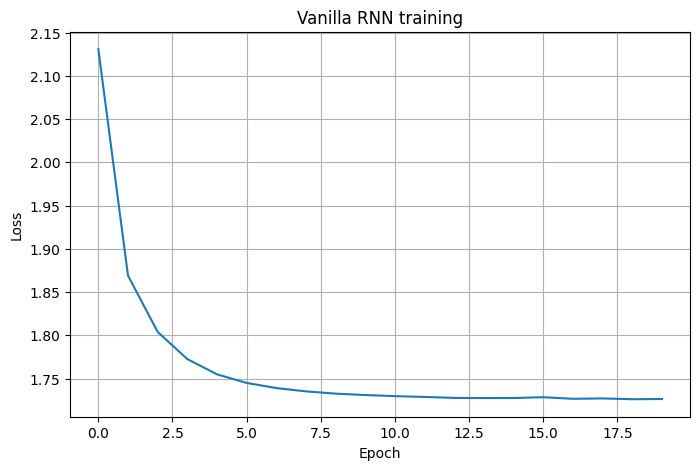

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla RNN training")
plt.grid(True)
plt.show()

In [12]:
import numpy as np
import torch
import torch.nn.functional as F

MAX_LENGTH = 300

def generate_sample(char_rnn,
                    seed_phrase='привет',
                    max_length=MAX_LENGTH,
                    temperature=1.0):

    char_rnn.eval()

    # кодируем начальную фразу
    sequence = [token_to_idx[ch] for ch in seed_phrase if ch in token_to_idx]

    hidden = char_rnn.init_hidden(batch_size=1)

    # скармливаем начальную фразу
    for idx in sequence[:-1]:
        x = torch.tensor([[idx]], dtype=torch.long)
        _, hidden = char_rnn(x, hidden)

    last_char = sequence[-1]

    # генерация текста
    for _ in range(max_length - len(sequence)):

        x = torch.tensor([[last_char]], dtype=torch.long)

        logits, hidden = char_rnn(x, hidden)

        logits = logits[:, -1, :]              # (1, vocab_size)

        probs = F.softmax(logits / temperature, dim=-1)

        next_char = torch.multinomial(probs, 1).item()

        sequence.append(next_char)

        last_char = next_char

    return ''.join(idx_for_token[idx] for idx in sequence)

print(generate_sample(
    model,
    seed_phrase='люб',
    max_length=400,
    temperature=0.8
))

люби_где_в_потомладиненья,всегом_их_жен_вижу,_романовсего_поклепрет_ее_нежних_танной_имее_спаславствхочновлекланья_не_столи_бые_скал_девы,_камнен_тоскрые_бесело_в_ковлеть_бурна,пытью_цельной_наети_полюбовь,как_пелиной.затяновстотою_волке_всё_краснойв_совет_без_лован_имееммас_приметыи_с_ним,_она_страстой,и_часто_лишки_пеленное_приклина,хавляя_блажен_в_камай,два_слушал_последсюднива,_говорить_мельпр


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [16]:
import torch
import torch.nn as nn

class CharLSTM(nn.Module):

    def __init__(self, vocab_size, emb_size=64, hidden_size=128):
        super().__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, emb_size)

        self.lstm = nn.LSTM(
            input_size=emb_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):

        x = self.embedding(x)

        out, hidden = self.lstm(x, hidden)

        out = self.fc(out)

        return out, hidden

    def init_hidden(self, batch_size):

        h0 = torch.zeros(1, batch_size, self.hidden_size)
        c0 = torch.zeros(1, batch_size, self.hidden_size)

        return (h0, c0)

In [17]:
model_lstm = CharLSTM(len(token_to_idx))

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_lstm.parameters(),
    lr=0.001
)

loss_history_lstm = []

EPOCHS = 20

for epoch in range(EPOCHS):

    epoch_loss = 0

    for x_batch, y_batch in train_dataloader:

        hidden = model_lstm.init_hidden(x_batch.size(0))

        optimizer.zero_grad()

        logits, hidden = model_lstm(x_batch, hidden)

        loss = criterion(
            logits.reshape(-1, len(token_to_idx)),
            y_batch.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_dataloader)
    loss_history_lstm.append(epoch_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}: loss = {epoch_loss:.4f}")

Epoch 1/20: loss = 2.0983
Epoch 2/20: loss = 1.7016
Epoch 3/20: loss = 1.5341
Epoch 4/20: loss = 1.4335
Epoch 5/20: loss = 1.3740
Epoch 6/20: loss = 1.3377
Epoch 7/20: loss = 1.3136
Epoch 8/20: loss = 1.2967
Epoch 9/20: loss = 1.2833
Epoch 10/20: loss = 1.2730
Epoch 11/20: loss = 1.2648
Epoch 12/20: loss = 1.2586
Epoch 13/20: loss = 1.2511
Epoch 14/20: loss = 1.2456
Epoch 15/20: loss = 1.2413
Epoch 16/20: loss = 1.2362
Epoch 17/20: loss = 1.2325
Epoch 18/20: loss = 1.2334
Epoch 19/20: loss = 1.2258
Epoch 20/20: loss = 1.2228


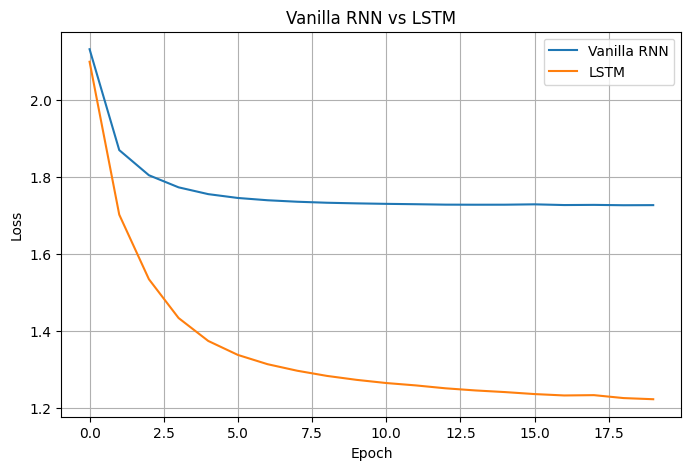

In [18]:
plt.figure(figsize=(8,5))
plt.plot(loss_history, label="Vanilla RNN")
plt.plot(loss_history_lstm, label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla RNN vs LSTM")
plt.grid(True)
plt.legend()
plt.show()

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [21]:
temperatures = [0.1, 0.2, 0.5, 1.0, 2.0]

for t in temperatures:
    print("=" * 60)
    print(f"Temperature = {t}")
    print("=" * 60)
    print(generate_sample(
        model_lstm,          # или model для Vanilla RNN
        seed_phrase="люб",
        max_length=300,
        temperature=t
    ))
    print()

Temperature = 0.1
любил_он_страшного_доныне,воскормы,чтобы_и_слезательно_подруги_в_ней_и_в_тишине,я_на_порой_ленский_на_светето_в_семьей,_татьяна_всех_найдетедет_она_забавлять,и_небружденной_нет,_нему_беспевнами,_волею_к_он_ее_чуднем,_как_моря_не_мог_он_ее_темноте_же,_волнадо_совершенный_взор,_как_он_мне_нет_онегиным

Temperature = 0.2
любил_он_на_полнавсюведний_взглядит.он_подава_летамартут_он_не_слушаей_вольности_сохраница_достался_долго_и_вновь_романая_про_небесначала_за_начудать_он_горей,_и_хоть_вы_неволе,и_был_на_плететесь_водом,или_блескним_менят_в_немоймеж_темности_нежным_вздор_всталелились_восповели_большое_взор_ее_много_д

Temperature = 0.5
любился,_как_явно_и_надела_татьяна_с_досади_бурных_двух_для_самом_деле,везды_волновались_вы_велить_в_деревне_оставиться_одут_в_осьмнадцать_чертит_меры,мелькаю_музиким_дверьв_два_одной,ни_слушай,_то_смущаюн_свой_искать_вас_одною_романых_княгине_был_страсти,_не_мог_он_заремился,_как_сожаленье_в_поле,и

Temperature = 1.0
люблю_я_всё_горды_игра

The "temperature" parameter controls the randomness of text generation. At low values ​​(0.1–0.2), the model almost always selects the most probable next character, resulting in text that is coherent but monotonous. A moderate value (0.5) strikes a good balance between variety and meaningfulness. At a temperature of 1.0, the text becomes more creative, though the error rate increases. At a temperature of 2.0, character selection becomes virtually random, leading to numerous nonsensical character sequences and a decline in text quality.

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [28]:
import os
import torch
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/models"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "char_lstm.pth")

torch.save(model_lstm.state_dict(), MODEL_PATH)

print("Model saved:", MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaded_model = CharLSTM(
    vocab_size=len(token_to_idx),
    emb_size=64,
    hidden_size=128
).to(device)

loaded_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

loaded_model.eval()

print("Model loaded successfully!")

print(generate_sample(
    loaded_model,
    seed_phrase="люб",
    max_length=300,
    temperature=0.5
))

Mounted at /content/drive
Model saved: /content/drive/MyDrive/models/char_lstm.pth
Model loaded successfully!
любил_он_утром_и_все_хотя_просить_не_приветы_вздор,вись_гордости_со_мной,всегда_наше_везде_подараманный_надежду_томном_словестиховно_полят_уж_страницы_далеком_уж_нетерпеливому_же_волею_к_поле,она_в_глуши_забытые_мне_теперь_на_балась_меня.пора_лиц_был_роковой,лишь_еще_на_солженьна_пора_нет_изменят_он


In [27]:
from google.colab import files

files.download("/content/models/char_lstm.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)